# **Tampil Data EKG Kalibrator**

In [ ]:
# ===== Import Libraries yang Digunakan =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [53]:
ekg = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Data Kalibrasi EKG Insmed/Insmed EKG-Konv1.csv")['ekg']
ekg = pd.to_numeric(ekg, errors='coerce')
ekg = ekg.dropna()

In [54]:
fs = 125
ekg_10 = ekg.iloc[:10*fs].values

In [55]:
def bandpass_filter(signal_data,lowcut=0.5,highcut=40,fs=125,order=6):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order,[low, high],btype='band')
    return filtfilt(b, a, signal_data)

ekg_bpf = bandpass_filter(ekg_10,lowcut=0.5,highcut=40,fs=fs,order=6)

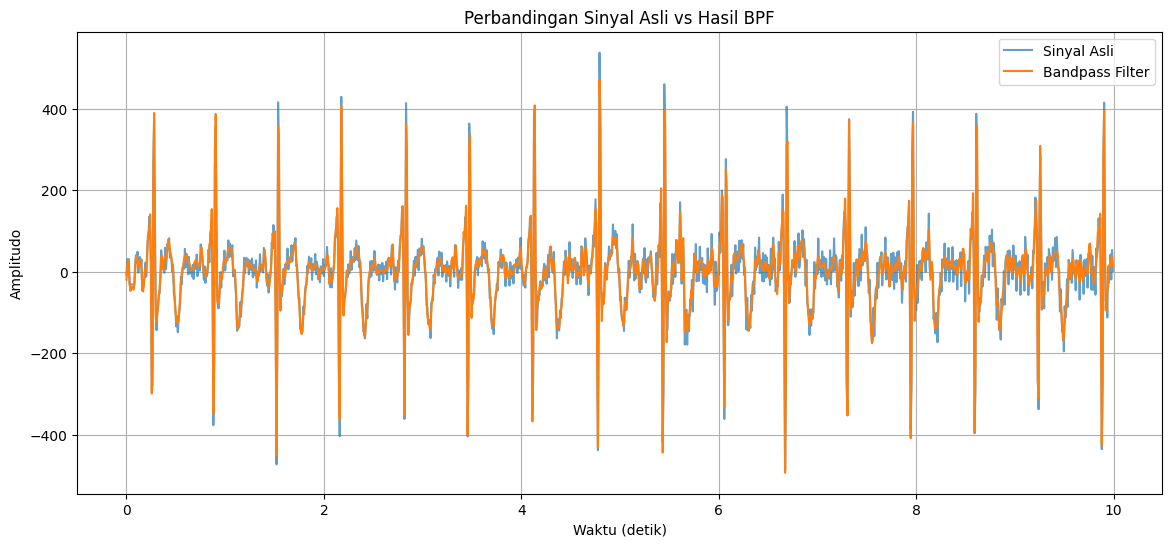

In [58]:
waktu = np.arange(len(ekg_10)) / fs

plt.figure(figsize=(14,6))
plt.plot(waktu, ekg_10,label='Sinyal Asli',alpha=0.7)
plt.plot(waktu, ekg_bpf,label='Bandpass Filter',linewidth=1.5)
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.title('Perbandingan Sinyal Asli vs Hasil BPF')
plt.grid(True)
plt.legend()
plt.show()

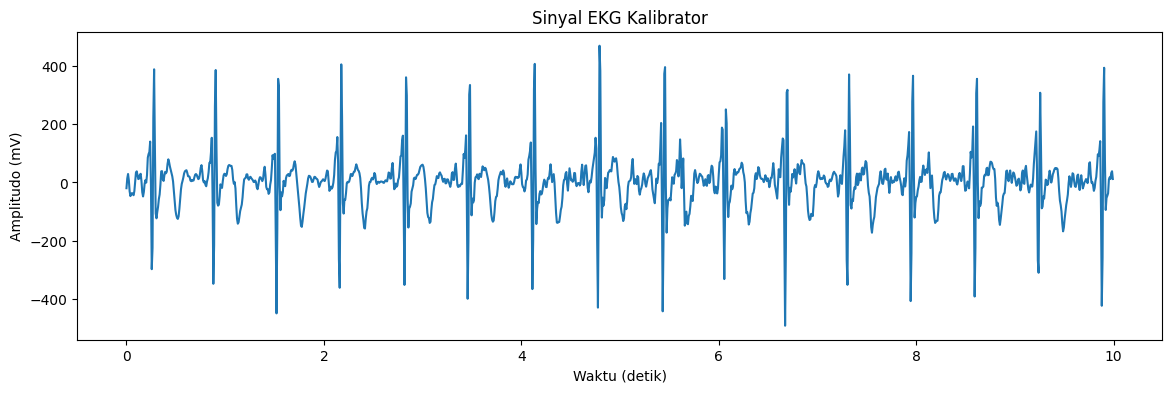

In [61]:
plt.figure(figsize=(14,4))
plt.plot(waktu, ekg_bpf)
plt.title('Sinyal EKG Kalibrator')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo (mV)')
plt.show()

# **Tampil Data Wearable EKG**

In [62]:
import pywt

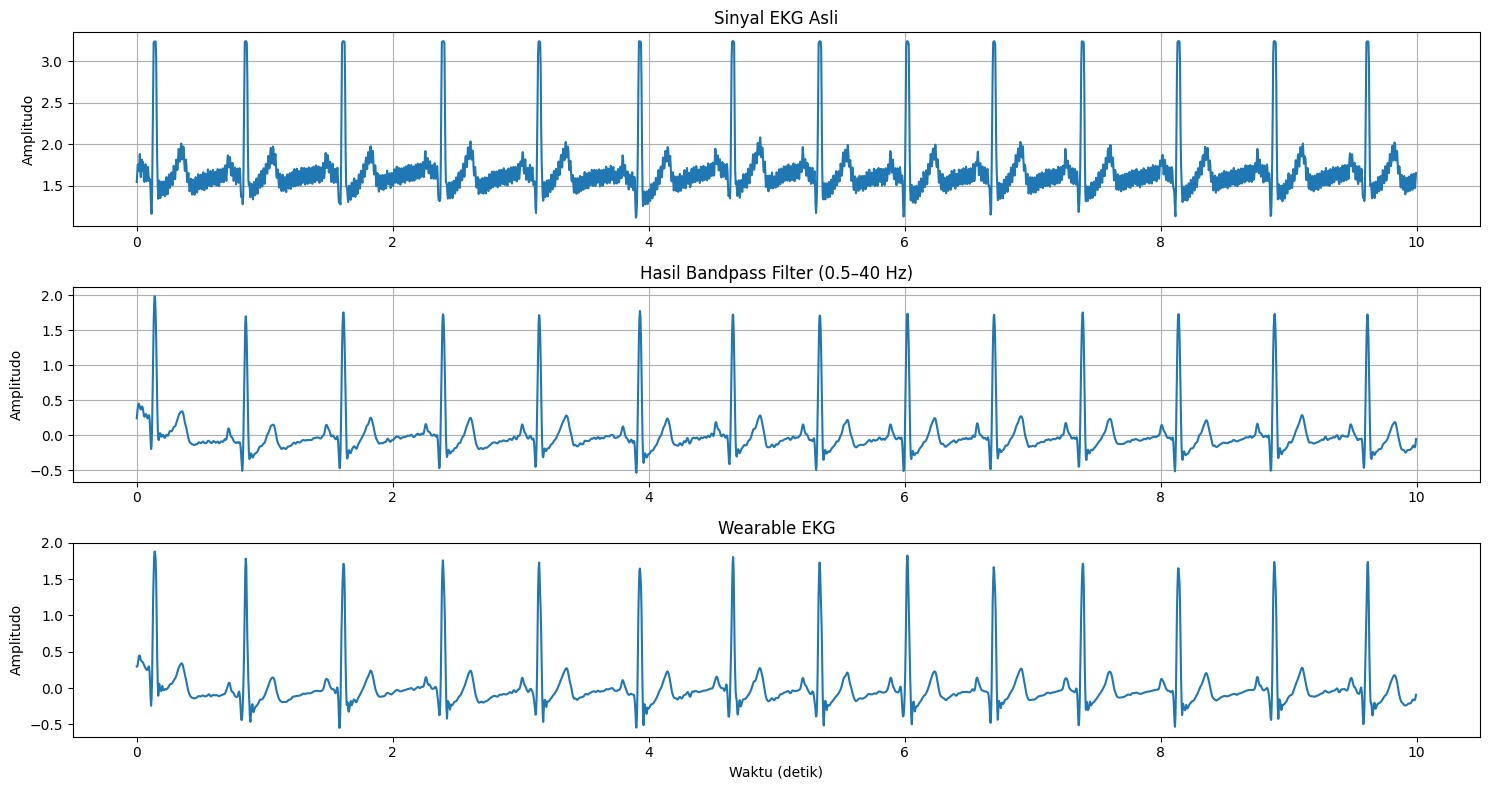

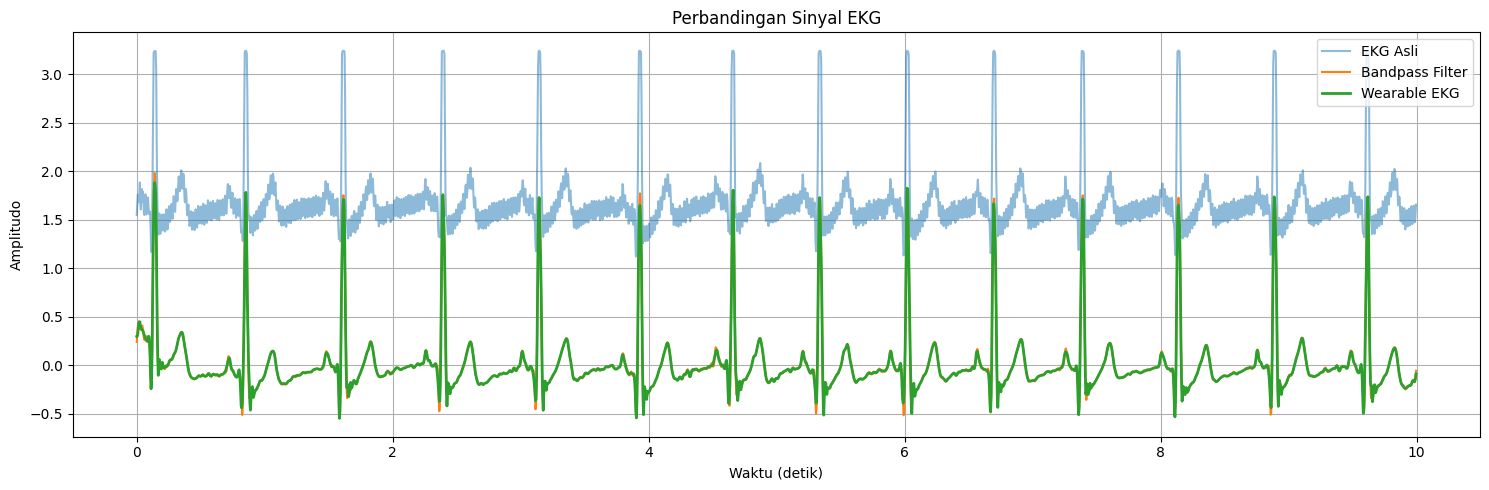

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt

from scipy.signal import butter, filtfilt

# =====================================================
# LOAD DATA
# =====================================================
df = pd.read_csv(
    "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Data Wearable EKG-Konv/Wearable EKG-Konv2_10 Menit.csv"
)

# Kolom EKG (kolom ke-3)
ekg = pd.to_numeric(df.iloc[:, 2], errors='coerce')
ekg = ekg.dropna().values

# =====================================================
# PARAMETER
# =====================================================
fs = 250          # Sampling Frequency
durasi = 10       # Detik

jumlah_sampel = fs * durasi

# Ambil 10 detik pertama
ekg_10 = ekg[:jumlah_sampel]

# =====================================================
# BANDPASS FILTER
# =====================================================
def bandpass_filter(signal_data,
                    lowcut=0.5,
                    highcut=40,
                    fs=250,
                    order=6):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    filtered_signal = filtfilt(
        b,
        a,
        signal_data
    )

    return filtered_signal

# =====================================================
# DWT DENOISING
# =====================================================
def denoise(signal_data):

    coeffs = pywt.wavedec(
        signal_data,
        wavelet='db5',
        level=5
    )

    cA5, cD5, cD4, cD3, cD2, cD1 = coeffs

    threshold = (
        np.median(np.abs(cD1))
        / 0.6745
    ) * np.sqrt(
        2 * np.log(len(cD1))
    )

    # Hilangkan noise frekuensi tinggi
    cD1.fill(0)
    cD2.fill(0)

    for i in range(1, len(coeffs)):
        coeffs[i] = pywt.threshold(
            coeffs[i],
            threshold,
            mode='soft'
        )

    reconstructed_signal = pywt.waverec(
        coeffs,
        wavelet='db5'
    )

    return reconstructed_signal[:len(signal_data)]

# =====================================================
# PREPROCESSING
# =====================================================
ekg_bpf = bandpass_filter(
    ekg_10,
    lowcut=0.5,
    highcut=40,
    fs=fs,
    order=6
)

ekg_dwt = denoise(ekg_bpf)

# =====================================================
# TIME AXIS
# =====================================================
waktu = np.arange(len(ekg_10)) / fs

# =====================================================
# PLOT 1
# ASLI - BPF - BPF+DWT
# =====================================================
plt.figure(figsize=(15,8))

plt.subplot(3,1,1)
plt.plot(waktu, ekg_10)
plt.title("Sinyal EKG Asli")
plt.ylabel("Amplitudo")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(waktu, ekg_bpf)
plt.title("Hasil Bandpass Filter (0.5–40 Hz)")
plt.ylabel("Amplitudo")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(waktu, ekg_dwt)
plt.title("Wearable EKG")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")


plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2
# OVERLAY
# =====================================================
plt.figure(figsize=(15,5))

plt.plot(
    waktu,
    ekg_10,
    label="EKG Asli",
    alpha=0.5
)

plt.plot(
    waktu,
    ekg_bpf,
    label="Bandpass Filter"
)

plt.plot(
    waktu,
    ekg_dwt,
    label="Wearable EKG",
    linewidth=2
)

plt.title("Perbandingan Sinyal EKG")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

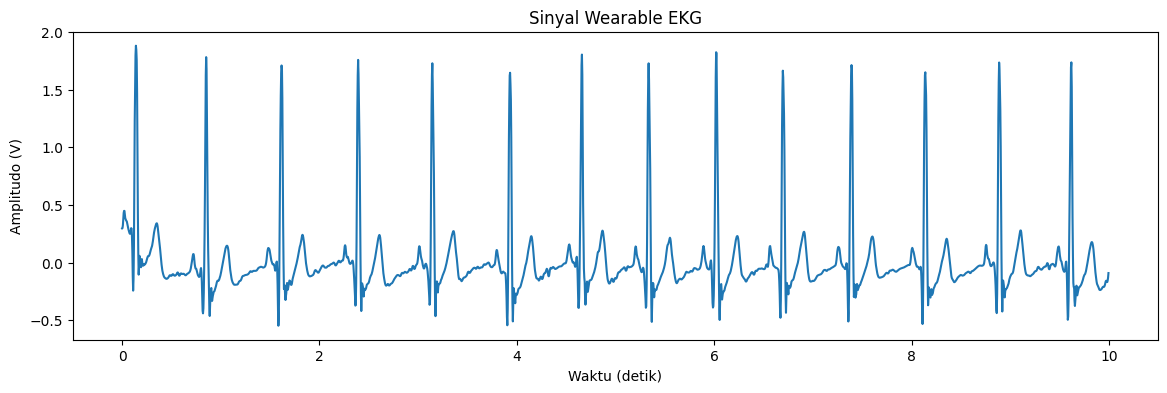

In [80]:
plt.figure(figsize=(14,4))
plt.plot(waktu, ekg_dwt)
plt.title("Sinyal Wearable EKG")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo (V)")
plt.show()